# Model 1: Temperature effect on normalized PV performance

This notebook implements the first Bayesian model for the PV project.

Research question:

$$ P(\beta_T < 0 | data) $$

Does higher PV module temperature decrease normalized PV performance?

The model uses preprocessed data. Expected columns:

- `logPR` and `x_T`

or alternatively:

- `PR` and `T_module_C`

where:

$$ x_T = \frac{T_m - 25}{10} $$

so one unit of `x_T` means a temperature increase of 10 degC.



## Model specification

The response variable is:

$$
y_i = \log(PR_i)
$$

The model is:

$$
y_i \sim StudentT(\nu, \mu_i, \sigma)
$$

$$
\mu_i = \alpha + \beta_T x_{T,i}
$$

where:

- $\alpha$ is the intercept, interpreted as the expected $\log(PR)$ when $x_T=0$, which corresponds to a module temperature of $T_m=25$ degC. On the original PR scale, $\exp(\alpha)$ is the expected normalized performance at this reference temperature. If the observed data contain few or no measurements close to 25 degC, this intercept should be treated mainly as a reference point for the regression line rather than as a directly observed operating condition.
- $\beta_T$ is the temperature coefficient. It is the expected change in $\log(PR)$ for a one-unit increase in $x_T$, i.e. for a 10 degC increase in module temperature. On the PR scale, $100(\exp(\beta_T)-1)$ is the approximate percentage change in normalized performance for a 10 degC increase. A negative value of $\beta_T$ therefore corresponds to temperature-related performance loss.
- $\sigma$ is residual variability around the mean relation.
- $\nu$ controls the tail heaviness of the Student-t distribution.

The Student-t likelihood is used instead of a normal likelihood because PV monitoring data can still contain atypical observations after preprocessing, for example due to short cloud passages, temporary shading, sensor noise, or inverter behaviour. The heavier tails make the model less sensitive to such remaining outliers.

The key quantity is:

$$
P(\beta_T < 0 \mid data)
$$

This posterior probability directly evaluates whether the data support a negative temperature effect on normalized PV performance.


In [1]:

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)

# Set to None if you want to use all data.
# During development 3000-5000 rows are enough and much faster.
MAX_N = 200

CLEAN_DATA_PATH = Path("onemin-Ground-2016/2016/clean_ground_2016_summer.csv")

print("Using clean data:", CLEAN_DATA_PATH)

STAN_MODEL_PATH = Path("model_1_temperature.stan")
STAN_PRIOR_PATH = Path("model_1_temperature_prior_predictive.stan")


Using clean data: onemin-Ground-2016/2016/clean_ground_2016_summer.csv


/Users/jwiater/Documents/private/da_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Load preprocessed data


In [2]:
df = pd.read_csv(CLEAN_DATA_PATH)

print("Raw data shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

if "logPR" not in df.columns:
    if "PR" not in df.columns:
        raise ValueError("Dataset must contain either 'logPR' or 'PR'.")
    df["logPR"] = np.log(df["PR"])

if "x_T" not in df.columns:
    if "T_module_C" not in df.columns:
        raise ValueError("Dataset must contain either 'x_T' or 'T_module_C'.")
    df["x_T"] = (df["T_module_C"] - 25.0) / 10.0

data = df[["logPR", "x_T"]].replace([np.inf, -np.inf], np.nan).dropna().copy()

if MAX_N is not None and len(data) > MAX_N:
    data = data.sample(n=MAX_N, random_state=RANDOM_SEED).sort_index()

print("Model data shape:", data.shape)
display(data.describe())

y = data["logPR"].to_numpy(dtype=float)
x_T = data["x_T"].to_numpy(dtype=float)
PR_obs = np.exp(y)
N = len(y)

stan_data = {
    "N": N,
    "x_T": x_T,
    "y": y,
}

prior_data = {
    "N": N,
    "x_T": x_T,
}


Raw data shape: (3558, 17)
Columns:
['timestamp', 'P_DC_kW', 'G_POA_Wm2', 'T_module_C', 'T_amb_C', 'wind_ms', 'hour', 'month', 'day', 'dG_POA', 'expected_P_DC_kW', 'PR', 'logPR', 'x_T', 'z_wind', 'z_Tamb', 'power_ratio']
Model data shape: (200, 2)


,logPR,x_T
count,200.000000,200.00000
mean,-0.115382,3.03815
std,0.030047,0.56728
min,-0.202842,0.41100
25%,-0.136969,2.71750
50%,-0.121970,3.14250
75%,-0.094767,3.45100
max,-0.035537,3.86900



## Exploratory plots


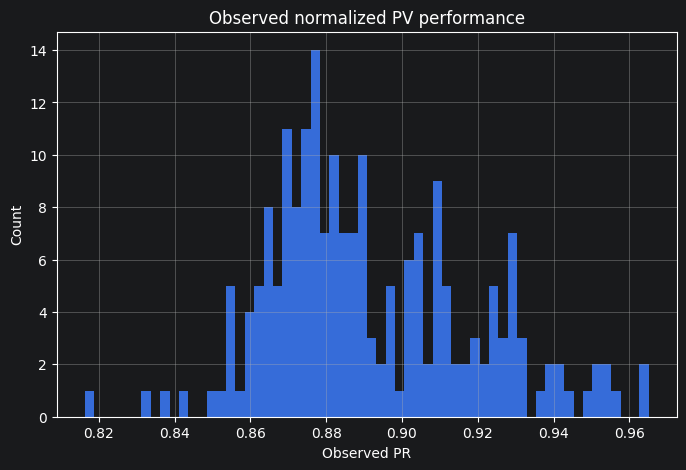

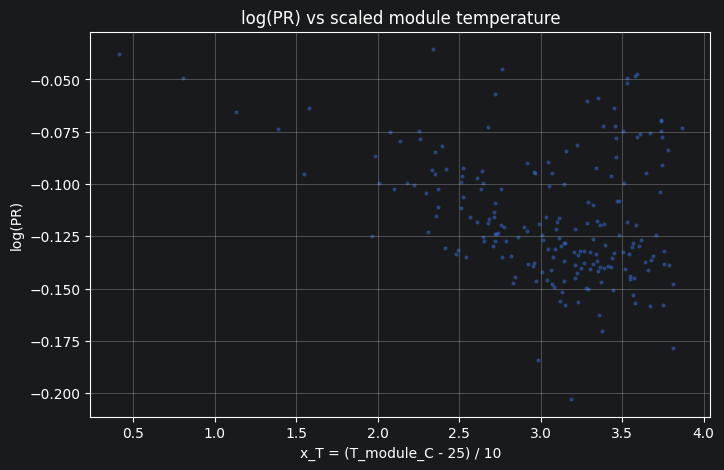

In [3]:

plt.figure(figsize=(8, 5))
plt.hist(PR_obs, bins=60)
plt.xlabel("Observed PR")
plt.ylabel("Count")
plt.title("Observed normalized PV performance")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x_T, y, s=4, alpha=0.4)
plt.xlabel("x_T = (T_module_C - 25) / 10")
plt.ylabel("log(PR)")
plt.title("log(PR) vs scaled module temperature")
plt.grid(True)
plt.show()



## Priors

The priors are weakly informative:

$$
\alpha \sim Normal(\log(0.85), 0.20)
$$

because normalized PV performance is expected to be below or near 1. This prior is placed on the log scale, so it represents prior beliefs about the expected PR at the reference temperature $T_m=25$ degC.

$$
\beta_T \sim Normal(0, 0.08)
$$

This prior does not force the effect to be negative. It allows either positive or negative temperature associations, while making very large changes in $\log(PR)$ per 10 degC unlikely.

$$
\sigma \sim Exponential(10)
$$

This prefers smaller residual variation, but allows larger noise if needed.

$$
\nu = 2 + Exponential(0.1)
$$

This gives a robust Student-t likelihood. Smaller values of $\nu$ allow heavier tails, while larger values make the likelihood closer to a normal distribution.



## Prior predictive checks


In [4]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH))

prior_fit = prior_model.sample(
    data=prior_data,
    fixed_param=True,
    chains=1,
    iter_sampling=2000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha:", np.percentile(alpha_prior, [2.5, 50, 97.5]))
print("Prior beta_T:", np.percentile(beta_T_prior, [2.5, 50, 97.5]))
print("Prior sigma:", np.percentile(sigma_prior, [2.5, 50, 97.5]))
print("Prior nu:", np.percentile(nu_prior, [2.5, 50, 97.5]))


23:20:29 - cmdstanpy - INFO - CmdStan start processing
chain 1: 100%|██████████| 3000/3000 [00:00<00:00, 9105.42it/s, (Sampling completed)]


23:20:29 - cmdstanpy - INFO - CmdStan done processing.



Prior alpha: [-0.74665803 -0.16416316  0.42313803]
Prior beta_T: [-0.15618494  0.00194099  0.16225765]
Prior sigma: [0.00301505 0.07028098 0.35413651]
Prior nu: [ 2.28888333  8.9172297  41.40750397]


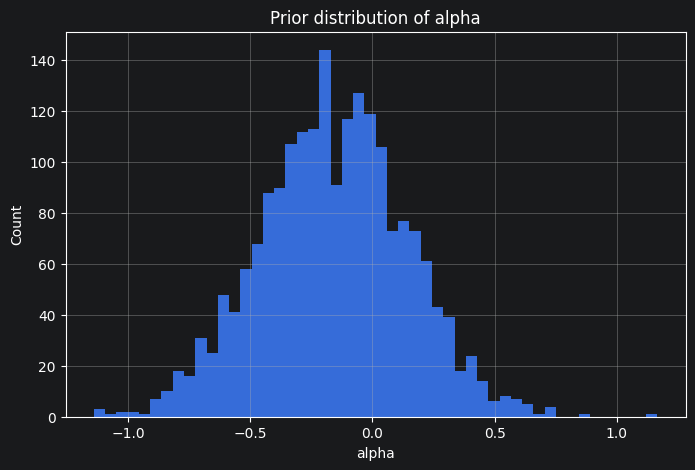

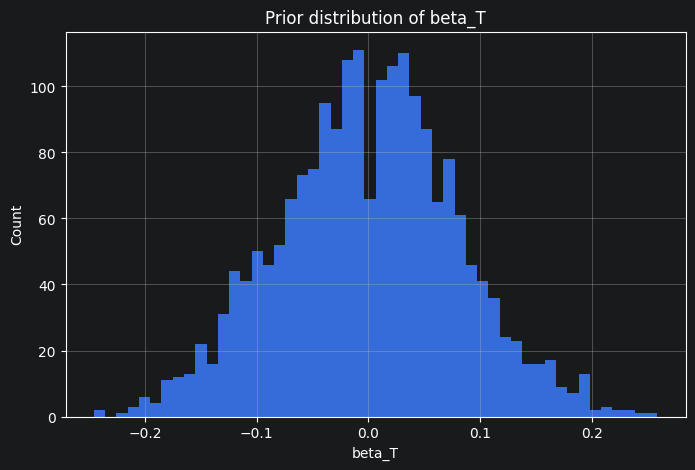

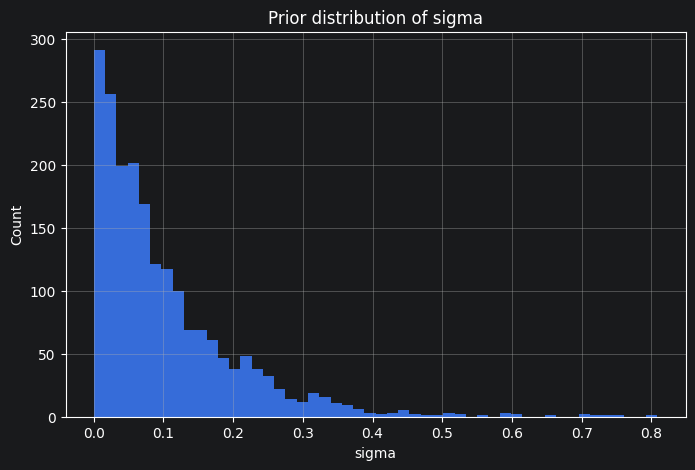

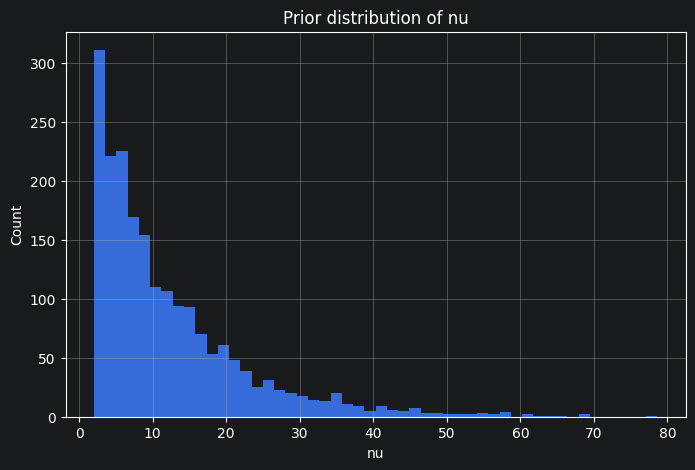

In [5]:

plt.figure(figsize=(8, 5))
plt.hist(alpha_prior, bins=50)
plt.xlabel("alpha")
plt.ylabel("Count")
plt.title("Prior distribution of alpha")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(beta_T_prior, bins=50)
plt.xlabel("beta_T")
plt.ylabel("Count")
plt.title("Prior distribution of beta_T")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sigma_prior, bins=50)
plt.xlabel("sigma")
plt.ylabel("Count")
plt.title("Prior distribution of sigma")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(nu_prior, bins=50)
plt.xlabel("nu")
plt.ylabel("Count")
plt.title("Prior distribution of nu")
plt.grid(True)
plt.show()


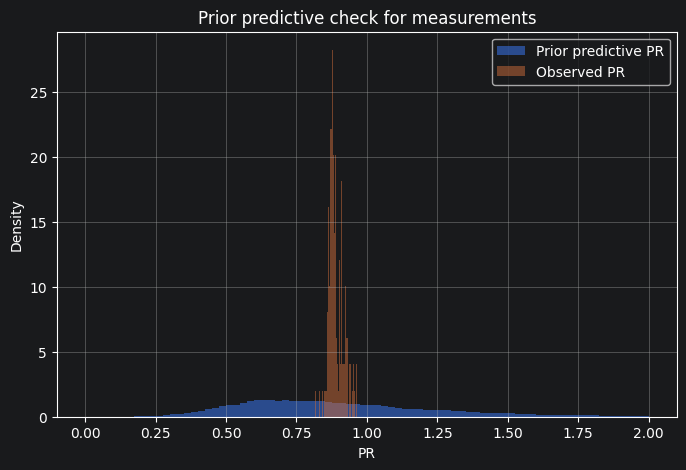

Prior predictive PR percentiles:
[0.30492742 0.43345819 0.84953801 1.71178004 2.37844304]


In [6]:

prior_flat = PR_prior.reshape(-1)
prior_flat = prior_flat[np.isfinite(prior_flat)]
prior_flat = prior_flat[(prior_flat > 0) & (prior_flat < 2.0)]

plt.figure(figsize=(8, 5))
plt.hist(prior_flat, bins=80, density=True, alpha=0.6, label="Prior predictive PR")
plt.hist(PR_obs, bins=60, density=True, alpha=0.5, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.legend()
plt.grid(True)
plt.show()

print("Prior predictive PR percentiles:")
print(np.percentile(PR_prior.reshape(-1), [1, 5, 50, 95, 99]))



## Fit Model 1


In [7]:

model = CmdStanModel(stan_file=str(STAN_MODEL_PATH))

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.90,
    max_treedepth=12,
)


23:20:30 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   5%|▌         | 100/2000 [00:00<00:05, 326.89it/s, (Warmup)]

chain 1:  30%|███       | 600/2000 [00:00<00:00, 1947.04it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:00<00:00, 1947.04it/s, (Sampling)]

chain 1:  55%|█████▌    | 1100/2000 [00:00<00:00, 2911.98it/s, (Sampling)]

chain 2:  50%|█████     | 1000/2000 [00:00<00:00, 1404.32it/s, (Sampling)]


chain 2:  55%|█████▌    | 1100/2000 [00:00<00:00, 2746.27it/s, (Sampling)]


chain 4:  50%|█████     | 1000/2000 [00:00<00:00, 1502.32it/s, (Sampling)]


chain 1:  75%|███████▌  | 1500/2000 [00:00<00:00, 2754.56it/s, (Sampling)]

chain 1:  95%|█████████▌| 1900/2000 [00:00<00:00, 2721.01it/s, (Sampling)]


chain 4:  80%|████████  | 1600/2000 [00:00<00:00, 2547.75it/s, (Sampling)]

cha


23:20:30 - cmdstanpy - INFO - CmdStan done processing.
23:20:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
Consider re-running with show_console=True if the above output is unclear!



## Sampling diagnostics

We check:

- divergences,
- R-hat,
- effective sample size.


In [8]:

print(fit.diagnose())

summary = fit.summary()
display(summary.loc[["alpha", "beta_T", "sigma", "nu"]])


divergences = fit.divergences
print("Number of divergences:", int(np.sum(divergences)))


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,-0.055371,0.000354,0.011510,0.011559,-0.074940,-0.054663,-0.037097,1071.680,1216.96,703.667,1.00477
beta_T,-0.020762,0.000129,0.004053,0.004062,-0.027277,-0.020945,-0.013977,1001.700,1227.82,657.715,1.00524
sigma,0.023811,0.000095,0.002883,0.003125,0.018899,0.023915,0.028306,931.594,1240.34,611.684,1.00718
nu,8.759770,0.219244,7.313290,4.071280,2.622120,6.224110,22.857300,890.748,1346.53,584.864,1.00420


Number of divergences: 0


## Posterior for beta_T

Because:

$$
x_T = \frac{T_m - 25}{10}
$$

the coefficient $\beta_T$ describes the effect of +10 degC on $\log(PR)$.

Effect in percent for +10 degC:

$$
100(\exp(\beta_T)-1)
$$

Effect in percent for +1 degC:

$$
100(\exp(\beta_T/10)-1)
$$


P(beta_T < 0 | data) = 1.0000
beta_T posterior percentiles:
[-0.02841403 -0.02094498 -0.01260641]
Effect per +10 degC [%] percentiles:
[-2.80141452 -2.07271544 -1.25272845]
Effect per +1 degC [%] percentiles:
[-0.28373698 -0.20923058 -0.1259847 ]


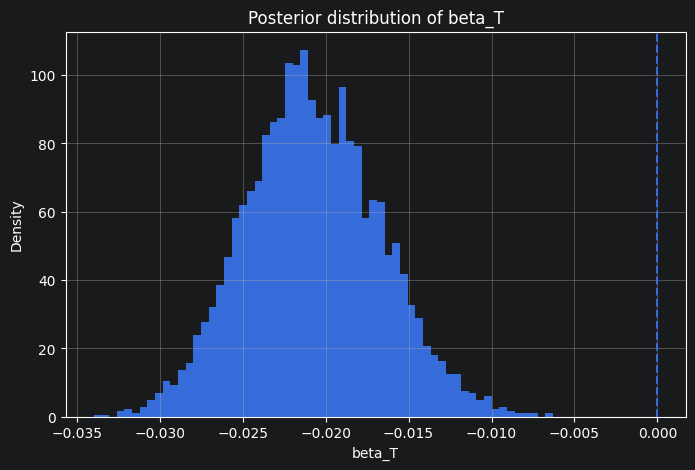

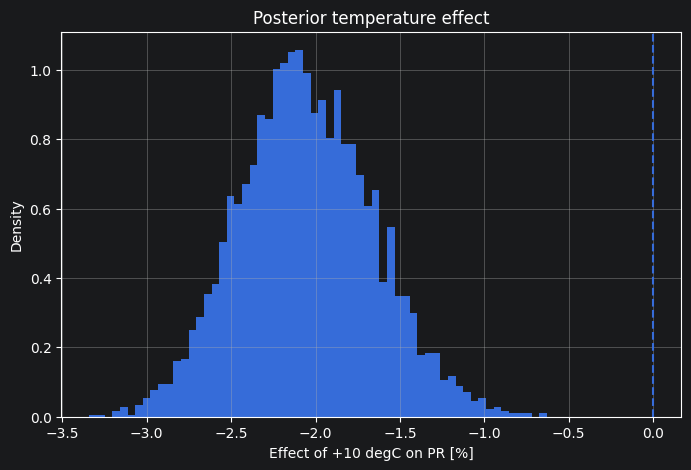

In [9]:

beta_T = fit.stan_variable("beta_T")

prob_negative = np.mean(beta_T < 0)
effect_10C_pct = 100 * (np.exp(beta_T) - 1)
effect_1C_pct = 100 * (np.exp(beta_T / 10) - 1)

print(f"P(beta_T < 0 | data) = {prob_negative:.4f}")
print("beta_T posterior percentiles:")
print(np.percentile(beta_T, [2.5, 50, 97.5]))

print("Effect per +10 degC [%] percentiles:")
print(np.percentile(effect_10C_pct, [2.5, 50, 97.5]))

print("Effect per +1 degC [%] percentiles:")
print(np.percentile(effect_1C_pct, [2.5, 50, 97.5]))

plt.figure(figsize=(8, 5))
plt.hist(beta_T, bins=60, density=True)
plt.axvline(0, linestyle="--")
plt.xlabel("beta_T")
plt.ylabel("Density")
plt.title("Posterior distribution of beta_T")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(effect_10C_pct, bins=60, density=True)
plt.axvline(0, linestyle="--")
plt.xlabel("Effect of +10 degC on PR [%]")
plt.ylabel("Density")
plt.title("Posterior temperature effect")
plt.grid(True)
plt.show()



## Posterior predictive checks


Observed PR percentiles [1, 5, 50, 95, 99]:
[0.83653418 0.85540088 0.88517511 0.94144961 0.95597462]
Posterior predictive PR percentiles [1, 5, 50, 95, 99]:
[0.81973137 0.84495368 0.88780775 0.93580998 0.96519929]
Observed mean PR: 0.8914
Posterior predictive mean PR: 0.8911
90% posterior predictive interval coverage: 0.875


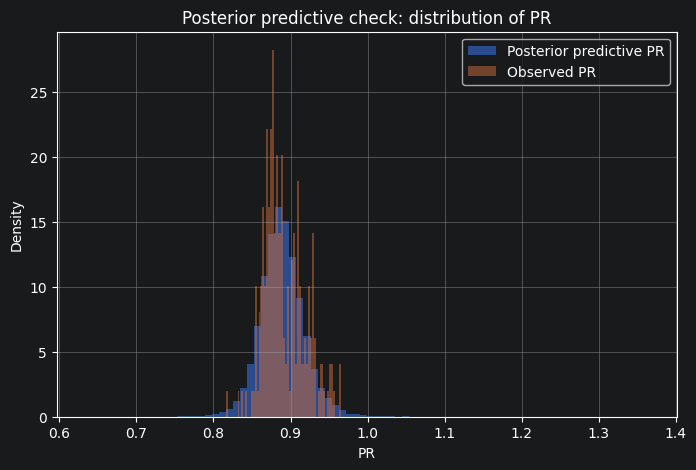

In [10]:

y_pred = fit.stan_variable("y_pred")
PR_pred = fit.stan_variable("PR_pred")

# Marginal posterior predictive check: compare the distribution of replicated PR
# values generated by the fitted model with the observed PR distribution.
idx = rng.choice(PR_pred.shape[0], size=min(200, PR_pred.shape[0]), replace=False)
PR_ppc_flat = PR_pred[idx, :].reshape(-1)
PR_ppc_flat = PR_ppc_flat[np.isfinite(PR_ppc_flat)]
PR_ppc_flat = PR_ppc_flat[(PR_ppc_flat > 0) & (PR_ppc_flat < 2.0)]

pred_low = np.percentile(PR_pred, 5, axis=0)
pred_high = np.percentile(PR_pred, 95, axis=0)
coverage_90 = np.mean((PR_obs >= pred_low) & (PR_obs <= pred_high))

print("Observed PR percentiles [1, 5, 50, 95, 99]:")
print(np.percentile(PR_obs, [1, 5, 50, 95, 99]))
print("Posterior predictive PR percentiles [1, 5, 50, 95, 99]:")
print(np.percentile(PR_pred.reshape(-1), [1, 5, 50, 95, 99]))
print(f"Observed mean PR: {np.mean(PR_obs):.4f}")
print(f"Posterior predictive mean PR: {np.mean(PR_pred):.4f}")
print(f"90% posterior predictive interval coverage: {coverage_90:.3f}")

plt.figure(figsize=(8, 5))
plt.hist(PR_ppc_flat, bins=80, density=True, alpha=0.6, label="Posterior predictive PR")
plt.hist(PR_obs, bins=60, density=True, alpha=0.5, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.legend()
plt.grid(True)
plt.show()


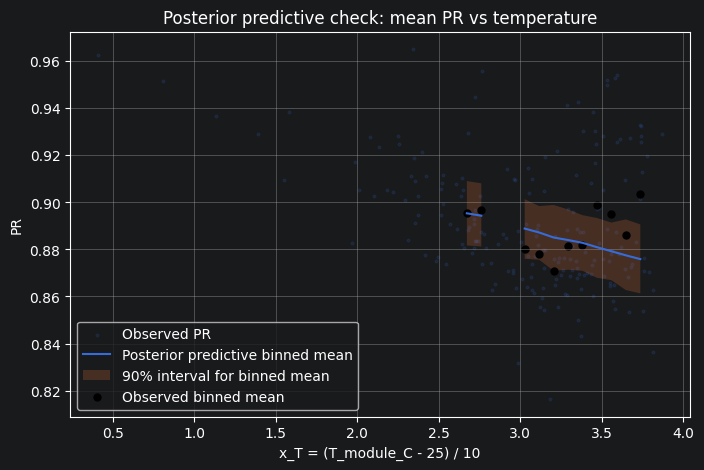

In [11]:

bins = np.linspace(x_T.min(), x_T.max(), 40)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

pred_mean = []
pred_low = []
pred_high = []
obs_mean = []
obs_count = []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (x_T >= lo) & (x_T < hi)
    obs_count.append(np.sum(mask))

    if np.sum(mask) < 10:
        pred_mean.append(np.nan)
        pred_low.append(np.nan)
        pred_high.append(np.nan)
        obs_mean.append(np.nan)
        continue

    # For each posterior draw, average replicated PR values within this
    # temperature bin. This checks whether the model reproduces the mean PR
    # trend by temperature, not the spread of individual points.
    pred_bin_mean = PR_pred[:, mask].mean(axis=1)

    pred_mean.append(np.mean(pred_bin_mean))
    pred_low.append(np.percentile(pred_bin_mean, 5))
    pred_high.append(np.percentile(pred_bin_mean, 95))
    obs_mean.append(np.mean(PR_obs[mask]))

pred_mean = np.array(pred_mean)
pred_low = np.array(pred_low)
pred_high = np.array(pred_high)
obs_mean = np.array(obs_mean)
obs_count = np.array(obs_count)

plt.figure(figsize=(8, 5))
plt.scatter(x_T, PR_obs, s=4, alpha=0.12, label="Observed PR")
plt.plot(bin_centers, pred_mean, label="Posterior predictive binned mean")
plt.fill_between(
    bin_centers,
    pred_low,
    pred_high,
    alpha=0.25,
    label="90% interval for binned mean",
)
plt.scatter(bin_centers, obs_mean, s=25, color="black", label="Observed binned mean")
plt.xlabel("x_T = (T_module_C - 25) / 10")
plt.ylabel("PR")
plt.title("Posterior predictive check: mean PR vs temperature")
plt.legend()
plt.grid(True)
plt.show()



## WAIC and PSIS-LOO

WAIC and PSIS-LOO are quantitative checks of the model predictive performance based on the pointwise log likelihood. They are most useful for comparing models fitted to the same response variable and dataset. Larger `elpd_waic` or `elpd_loo` values indicate better expected out-of-sample predictive performance. The `p_waic` and `p_loo` values describe the effective model complexity.

For PSIS-LOO, the `pareto_k` diagnostics should also be checked: values below 0.5 are good, values between 0.5 and 0.7 are usually acceptable, and values above 0.7 indicate influential observations for which the approximation may be unreliable. In this notebook, WAIC is computed directly from the pointwise `log_lik` values saved by Stan.


In [12]:

from scipy.special import logsumexp

idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

# WAIC from pointwise posterior log likelihood.
log_lik = idata1.log_likelihood["log_lik"].values
n_obs = log_lik.shape[-1]
log_lik_samples = log_lik.reshape((-1, n_obs))

lppd_i = logsumexp(log_lik_samples, axis=0) - np.log(log_lik_samples.shape[0])
p_waic_i = np.var(log_lik_samples, axis=0, ddof=1)
elpd_waic_i = lppd_i - p_waic_i

elpd_waic = np.sum(elpd_waic_i)
p_waic = np.sum(p_waic_i)
waic = -2 * elpd_waic
se_elpd_waic = np.sqrt(n_obs * np.var(elpd_waic_i, ddof=1))

waic_summary = pd.DataFrame(
    {
        "Estimate": [elpd_waic, p_waic, waic],
        "SE": [se_elpd_waic, np.nan, 2 * se_elpd_waic],
    },
    index=["elpd_waic", "p_waic", "waic"],
)

print("WAIC:")
display(waic_summary)

loo_result = az.loo(idata1)

print("PSIS-LOO:")
display(loo_result)

pareto_k = loo_result.pareto_k.values
print("Pareto k diagnostics:")
print(f"max Pareto k: {pareto_k.max():.3f}")
print(f"proportion Pareto k > 0.7: {np.mean(pareto_k > 0.7):.3f}")


WAIC:


,Estimate,SE
elpd_waic,425.095742,12.676498
p_waic,5.826047,NaN
waic,-850.191484,25.352995


PSIS-LOO:


Computed from 4000 posterior samples and 200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   425.10    12.64
p_loo        5.82        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      200  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

Pareto k diagnostics:
max Pareto k: 0.227
proportion Pareto k > 0.7: 0.000



## Interpretation

Model 1 estimates the empirical association between module temperature and normalized PV performance using temperature as the only predictor. The posterior probability that the temperature coefficient is negative was 1.0, which indicates strong support for a negative temperature effect under this model. The median effect of a +10 degC increase in module temperature was -1.87%, with a 95% credible interval of [-2.00%, -1.74%]. Because wind speed is not included explicitly, possible wind-related cooling effects remain part of the unexplained variation, so the result should be interpreted as a temperature-only association rather than a complete causal explanation.



## Save ArviZ object for model comparison

The ArviZ object created above is saved so it can be reused later for model comparison without rebuilding it from the CmdStan fit object.


In [13]:

if "idata1" not in globals():
    idata1 = az.from_cmdstanpy(
        posterior=fit,
        posterior_predictive=["y_pred"],
        observed_data={"y": y},
        log_likelihood=["log_lik"],
    )

with open("idata_model1_temperature.pkl", "wb") as f:
    pickle.dump(idata1, f)

print("Saved idata_model1_temperature.pkl")


Saved idata_model1_temperature.pkl
